# Brent MM — Lead/Lag Analysis with Prices (as of date join)

Brent positioning comes from **two independent sources**:
- ICE Futures Europe (primary — the CO benchmark)
- CFTC/NYMEX (4 flat price contracts)

We sum positions across both sources per report date.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1. Load Brent COT from ICE + CFTC

In [2]:
# --- ICE Europe: primary Brent contract ---
ICE_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cot-ingest/downloads/ice/ice_cot.csv'
ice = pd.read_csv(ICE_PATH, low_memory=False)

# Use Combined (F+O) where available, Futures-only as fallback
BRENT_COMBINED = 'ICE Brent Crude Futures and Options - ICE Futures Europe'
BRENT_FUTURES  = 'ICE Brent Crude Futures - ICE Futures Europe'

br_comb = ice[ice['Market_and_Exchange_Names'] == BRENT_COMBINED].copy()
br_fut  = ice[ice['Market_and_Exchange_Names'] == BRENT_FUTURES].copy()

for df in [br_comb, br_fut]:
    df['as_of_date'] = pd.to_datetime(df['As_of_Date_Form_MM/DD/YYYY'])

combined_start = br_comb['as_of_date'].min()
br_early = br_fut[br_fut['as_of_date'] < combined_start]
br_ice = pd.concat([br_early, br_comb], ignore_index=True)

# Standardise column names to match CFTC
ICE_COLS = {
    'Open_Interest_All': 'oi',
    'M_Money_Positions_Long_All': 'mm_long',
    'M_Money_Positions_Short_All': 'mm_short',
}
for old, new in ICE_COLS.items():
    br_ice[new] = pd.to_numeric(br_ice[old], errors='coerce')
br_ice = br_ice[['as_of_date', 'oi', 'mm_long', 'mm_short']].copy()
br_ice['source'] = 'ICE'

print(f'ICE Brent: {len(br_ice)} rows, {br_ice["as_of_date"].min().date()} -> {br_ice["as_of_date"].max().date()}')


ICE Brent: 909 rows, 2011-01-04 -> 2026-03-24


In [3]:
# --- CFTC/NYMEX: Brent flat price contracts ---
CFTC_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cftc_data/cftc_downloads/disaggregated_combined.csv'
cftc = pd.read_csv(CFTC_PATH, low_memory=False)

# All Brent flat price codes (from cot-ingest/docs/brent_cot_mapping.md)
BRENT_CFTC_CODES = [
    '06765J',  # BRENT FINANCIAL (cash-settled)
    '06765T',  # BRENT CRUDE OIL LAST DAY (physical)
    '06765Y',  # BRENT AVG PRICE OPTIONS
    '06765X',  # EUR STYLE BRENT OPTIONS
]

br_cftc = cftc[cftc['cftc_contract_market_code'].isin(BRENT_CFTC_CODES)].copy()
br_cftc['as_of_date'] = pd.to_datetime(br_cftc['report_date_as_yyyy_mm_dd'])

for c in ['open_interest_all', 'm_money_positions_long_all', 'm_money_positions_short_all']:
    br_cftc[c] = pd.to_numeric(br_cftc[c], errors='coerce')

# Sum across NYMEX codes per date
br_nymex = br_cftc.groupby('as_of_date').agg(
    oi=('open_interest_all', 'sum'),
    mm_long=('m_money_positions_long_all', 'sum'),
    mm_short=('m_money_positions_short_all', 'sum'),
).reset_index()
br_nymex['source'] = 'CFTC'

print(f'CFTC Brent: {len(br_nymex)} rows, {br_nymex["as_of_date"].min().date()} -> {br_nymex["as_of_date"].max().date()}')


CFTC Brent: 916 rows, 2008-04-15 -> 2026-03-24


In [4]:
# --- Combine ICE + CFTC ---
# Sum positions from both sources for each date
combined = pd.concat([br_ice, br_nymex], ignore_index=True)
brent = combined.groupby('as_of_date').agg(
    oi=('oi', 'sum'),
    mm_long=('mm_long', 'sum'),
    mm_short=('mm_short', 'sum'),
).reset_index()

brent['mm_net'] = brent['mm_long'] - brent['mm_short']
brent['mm_net_oi'] = brent['mm_net'] / brent['oi'] * 100
days_ahead = (4 - brent['as_of_date'].dt.dayofweek) % 7
brent['release_date'] = brent['as_of_date'] + pd.to_timedelta(days_ahead, unit='D')
brent.sort_values('as_of_date', inplace=True)
brent.reset_index(drop=True, inplace=True)

print(f'Combined Brent: {len(brent)} rows')
print(f'Range: {brent["as_of_date"].min().date()} -> {brent["as_of_date"].max().date()}')


Combined Brent: 923 rows
Range: 2008-04-15 -> 2026-03-24


## 2. Load prices and join

In [5]:
prices = pd.read_csv('../../../../cache/preprocessed_data/br_prices_panel.csv',
                      usecols=['tradeDate', 'F1_RolledPrice'])
prices['tradeDate'] = pd.to_datetime(prices['tradeDate'])
prices.sort_values('tradeDate', inplace=True)

# Join on as_of_date
prices_renamed = prices.rename(columns={'tradeDate': 'as_of_date'})
df = brent.merge(prices_renamed, on='as_of_date', how='inner')

print(f'Joined rows: {len(df)}')
print(f'Range: {df["as_of_date"].min().date()} -> {df["as_of_date"].max().date()}')


Joined rows: 841
Range: 2010-01-05 -> 2026-03-24


In [6]:
df.sort_values('as_of_date', inplace=True)
df.reset_index(drop=True, inplace=True)

df['mm_net_chg']    = df['mm_net'].diff()
df['mm_net_oi_chg'] = df['mm_net_oi'].diff()
df['price_ret']     = df['F1_RolledPrice'].pct_change() * 100

df.dropna(subset=['mm_net_chg', 'price_ret'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Clean rows: {len(df)}')


Clean rows: 840


## 3. Contemporaneous correlation

In [7]:
rho, p = sp_stats.spearmanr(df['mm_net_chg'], df['price_ret'])
rho_oi, p_oi = sp_stats.spearmanr(df['mm_net_oi_chg'], df['price_ret'])
print('Contemporaneous (same week):')
print(f'  MM net change vs price return:    rho = {rho:+.3f}  (p = {p:.1e})')
print(f'  MM net/OI change vs price return: rho = {rho_oi:+.3f}  (p = {p_oi:.1e})')


Contemporaneous (same week):
  MM net change vs price return:    rho = +0.220  (p = 1.1e-10)
  MM net/OI change vs price return: rho = +0.209  (p = 1.0e-09)


## 4. Cross-correlation function (Tuesday-Tuesday)

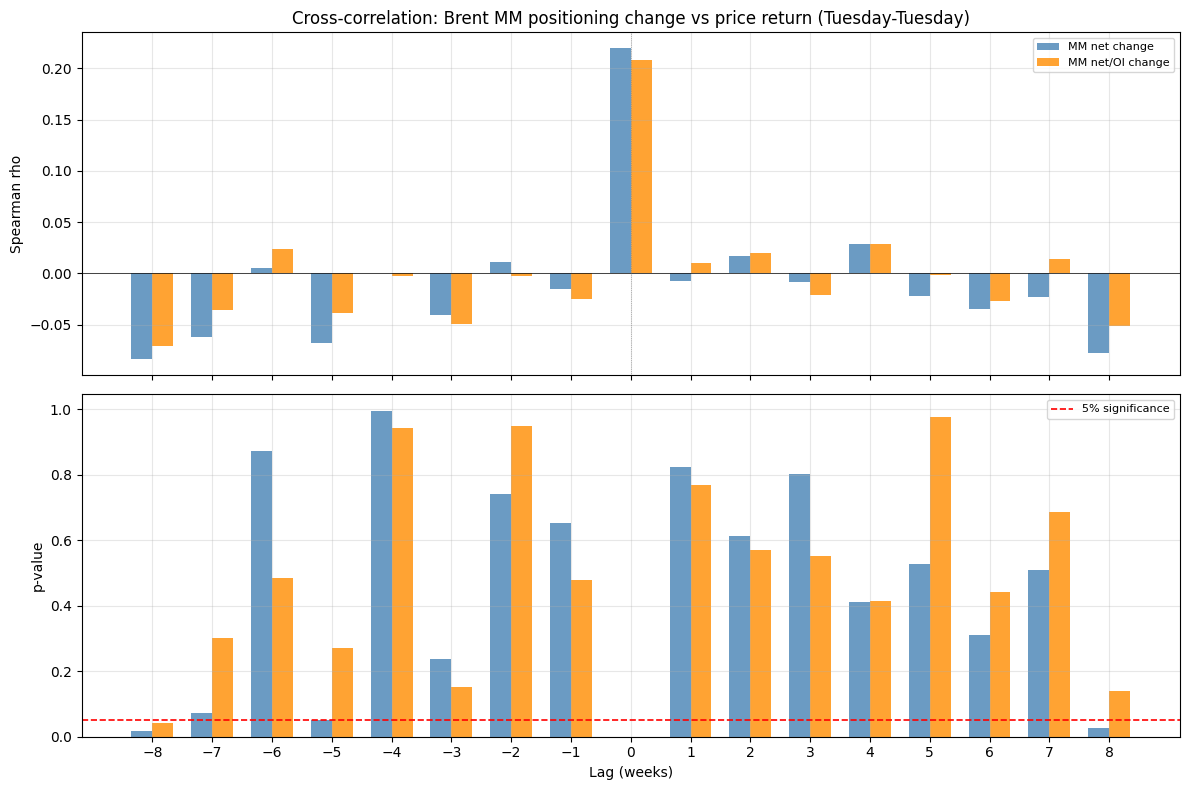

 Lag   rho (raw)       p-val    rho (OI)       p-val
-------------------------------------------------------
  -8     -0.084 *     1.6e-02     -0.071 *     4.2e-02
  -7     -0.062       7.3e-02     -0.036       3.0e-01
  -6     +0.006       8.7e-01     +0.024       4.8e-01
  -5     -0.068       5.0e-02     -0.038       2.7e-01
  -4     +0.000       9.9e-01     -0.003       9.4e-01
  -3     -0.041       2.4e-01     -0.049       1.5e-01
  -2     +0.011       7.4e-01     -0.002       9.5e-01
  -1     -0.016       6.5e-01     -0.025       4.8e-01
   0     +0.220 *     1.1e-10     +0.209 *     1.0e-09
   1     -0.008       8.2e-01     +0.010       7.7e-01
   2     +0.017       6.1e-01     +0.020       5.7e-01
   3     -0.009       8.0e-01     -0.021       5.5e-01
   4     +0.029       4.1e-01     +0.028       4.1e-01
   5     -0.022       5.3e-01     -0.001       9.8e-01
   6     -0.035       3.1e-01     -0.027       4.4e-01
   7     -0.023       5.1e-01     +0.014       6.9e-01
   8     -0

In [8]:
MAX_LAG = 8

def compute_ccf(x, y, max_lag):
    lags = range(-max_lag, max_lag + 1)
    rhos, pvals = [], []
    for k in lags:
        if k >= 0:
            rho, p = sp_stats.spearmanr(x[:len(x)-k], y[k:])
        else:
            rho, p = sp_stats.spearmanr(x[-k:], y[:len(y)+k])
        rhos.append(rho)
        pvals.append(p)
    return list(lags), rhos, pvals

net_vals = df['mm_net_chg'].values
oi_vals = df['mm_net_oi_chg'].values
price_vals = df['price_ret'].values

lags, rhos_raw, pvals_raw = compute_ccf(net_vals, price_vals, MAX_LAG)
_, rhos_oi, pvals_oi = compute_ccf(oi_vals, price_vals, MAX_LAG)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
bar_width = 0.35
x_pos = np.array(lags)

ax = axes[0]
ax.bar(x_pos - bar_width/2, rhos_raw, bar_width, color='steelblue', alpha=0.8, label='MM net change')
ax.bar(x_pos + bar_width/2, rhos_oi, bar_width, color='darkorange', alpha=0.8, label='MM net/OI change')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_ylabel('Spearman rho')
ax.set_title('Cross-correlation: Brent MM positioning change vs price return (Tuesday-Tuesday)')
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(x_pos - bar_width/2, pvals_raw, bar_width, color='steelblue', alpha=0.8)
ax.bar(x_pos + bar_width/2, pvals_oi, bar_width, color='darkorange', alpha=0.8)
ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% significance')
ax.set_ylabel('p-value')
ax.set_xlabel('Lag (weeks)')
ax.set_xticks(lags)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'{"Lag":>4s}  {"rho (raw)":>10s}  {"p-val":>10s}  {"rho (OI)":>10s}  {"p-val":>10s}')
print('-' * 55)
for k, rr, pr, ro, po in zip(lags, rhos_raw, pvals_raw, rhos_oi, pvals_oi):
    sig_r = '*' if pr < 0.05 else ' '
    sig_o = '*' if po < 0.05 else ' '
    print(f'{k:>4d}  {rr:>+9.3f} {sig_r}  {pr:>10.1e}  {ro:>+9.3f} {sig_o}  {po:>10.1e}')


## 5. 2-year blocks

In [9]:
df['year'] = df['as_of_date'].dt.year
blocks_2y = [
    ('2011-2012', (2011, 2012)), ('2013-2014', (2013, 2014)),
    ('2015-2016', (2015, 2016)), ('2017-2018', (2017, 2018)),
    ('2019-2020', (2019, 2020)), ('2021-2022', (2021, 2022)),
    ('2023-2025', (2023, 2025)),
]
KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY: print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))
for label, (y_start, y_end) in blocks_2y + [('Full sample', (2011, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    pr_b = sub['price_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                pr_b[k:] if k > 0 else pr_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], pr_b[:len(pr_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()


       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2011-2012   104  -0.039  +0.024  +0.766  -0.032  -0.038
   2013-2014   104  -0.093  +0.267  +0.506  +0.112  -0.117
   2015-2016   104  +0.099  -0.160  -0.350  +0.072  -0.020
   2017-2018   105  -0.057  -0.160  +0.024  +0.081  +0.175
   2019-2020   105  +0.088  +0.051  +0.083  -0.049  +0.046
   2021-2022   104  +0.008  +0.058  +0.443  +0.113  +0.063
   2023-2025   158  -0.065  +0.079  +0.708  -0.280  -0.022
 Full sample   784  -0.002  -0.023  +0.226  -0.013  +0.016


## 5b. CCF by 5-year blocks

Is the lead/lag structure stable across different market regimes,
or is the full-sample CCF dominated by a particular period?

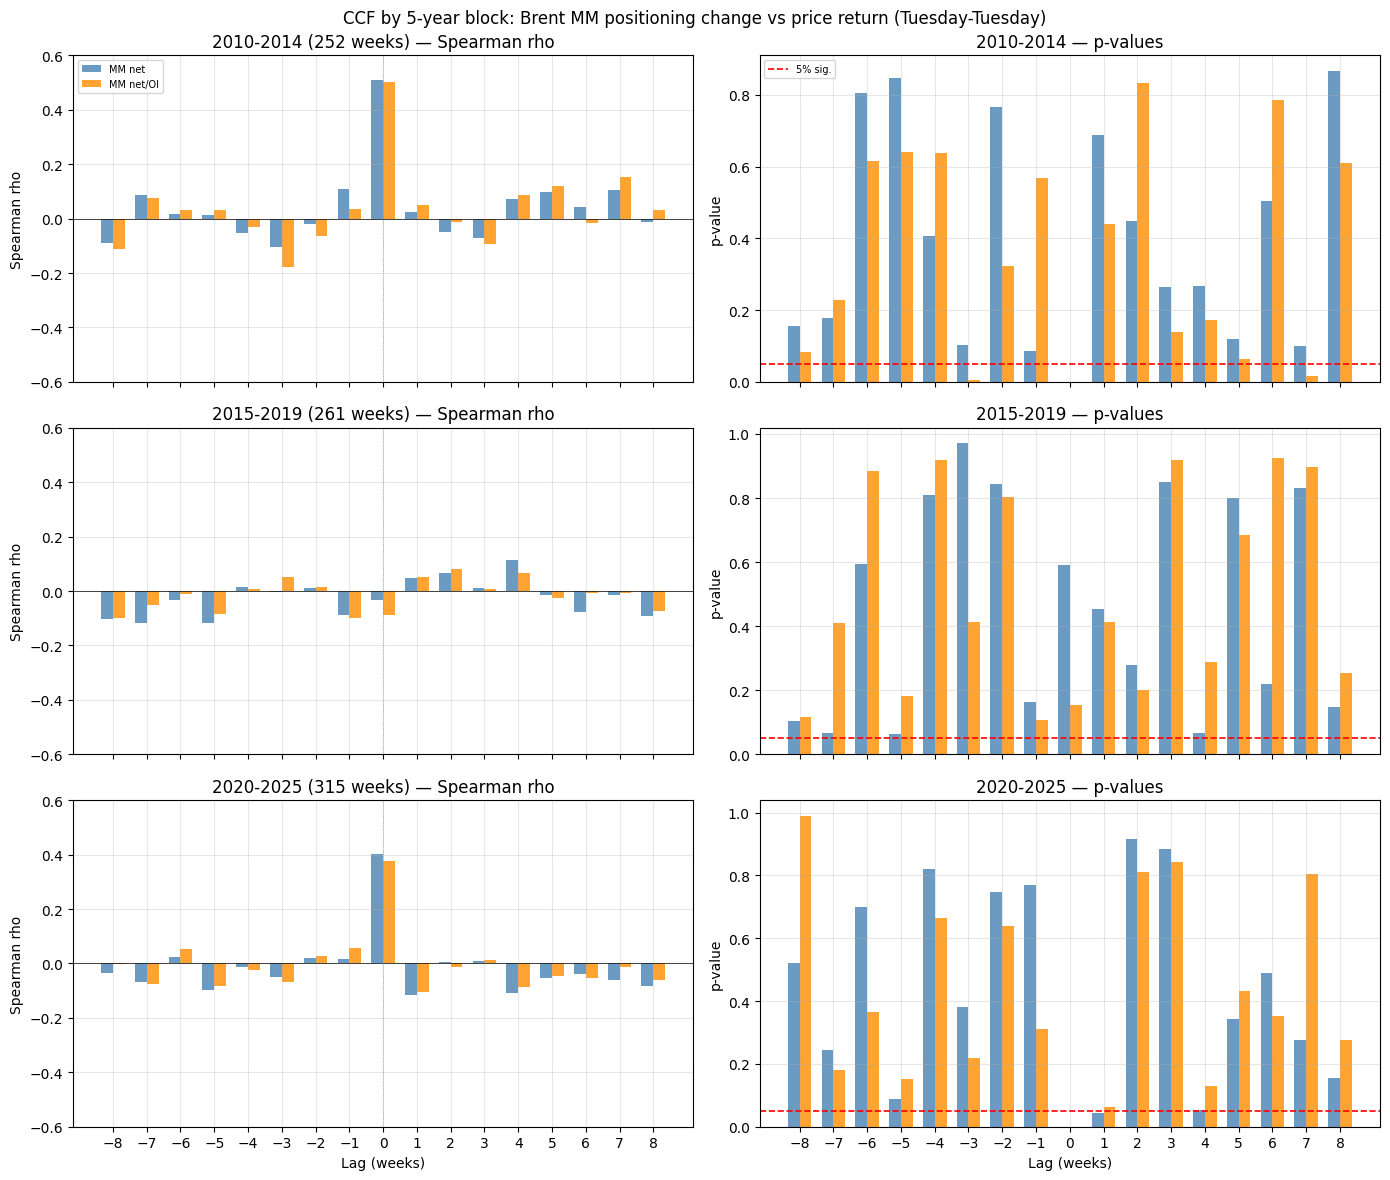

In [10]:
# Define 5-year blocks
blocks_5y = [
    ('2010-2014', (2010, 2014)),
    ('2015-2019', (2015, 2019)),
    ('2020-2025', (2020, 2025)),
]

fig, axes = plt.subplots(len(blocks_5y), 2, figsize=(14, 4 * len(blocks_5y)),
                         sharex=True)
bar_width = 0.35

for row, (label, (y_start, y_end)) in enumerate(blocks_5y):
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    mm_oi_b = sub['mm_net_oi_chg'].values
    pr_b = sub['price_ret'].values

    lags_b, rhos_raw_b, pvals_raw_b = compute_ccf(mm_b, pr_b, MAX_LAG)
    _, rhos_oi_b, pvals_oi_b = compute_ccf(mm_oi_b, pr_b, MAX_LAG)
    x_pos = np.array(lags_b)

    ax = axes[row, 0]
    ax.bar(x_pos - bar_width/2, rhos_raw_b, bar_width,
           color='steelblue', alpha=0.8, label='MM net')
    ax.bar(x_pos + bar_width/2, rhos_oi_b, bar_width,
           color='darkorange', alpha=0.8, label='MM net/OI')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5, linestyle=':')
    ax.set_ylabel('Spearman rho')
    ax.set_title(f'{label} ({len(sub)} weeks) — Spearman rho')
    ax.set_ylim(-0.6, 0.6)
    if row == 0:
        ax.legend(fontsize=7, loc='upper left')

    ax = axes[row, 1]
    ax.bar(x_pos - bar_width/2, pvals_raw_b, bar_width,
           color='steelblue', alpha=0.8)
    ax.bar(x_pos + bar_width/2, pvals_oi_b, bar_width,
           color='darkorange', alpha=0.8)
    ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% sig.')
    ax.set_ylabel('p-value')
    ax.set_title(f'{label} — p-values')
    ax.set_xticks(lags_b)
    if row == 0:
        ax.legend(fontsize=7)

axes[-1, 0].set_xlabel('Lag (weeks)')
axes[-1, 1].set_xlabel('Lag (weeks)')
plt.suptitle('CCF by 5-year block: Brent MM positioning change vs price return (Tuesday-Tuesday)',
             fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY:
    print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))

for label, (y_start, y_end) in blocks_5y + [('Full sample', (2010, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    pr_b = sub['price_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                pr_b[k:] if k > 0 else pr_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], pr_b[:len(pr_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()

       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2014   252  -0.019  +0.108  +0.509  +0.025  -0.048
   2015-2019   261  +0.012  -0.087  -0.033  +0.047  +0.067
   2020-2025   315  +0.018  +0.017  +0.403  -0.114  +0.006
 Full sample   828  +0.006  -0.018  +0.215  -0.011  +0.016


## 5c. CCF by 3-year blocks

Finer granularity to see how the lead/lag structure evolves.

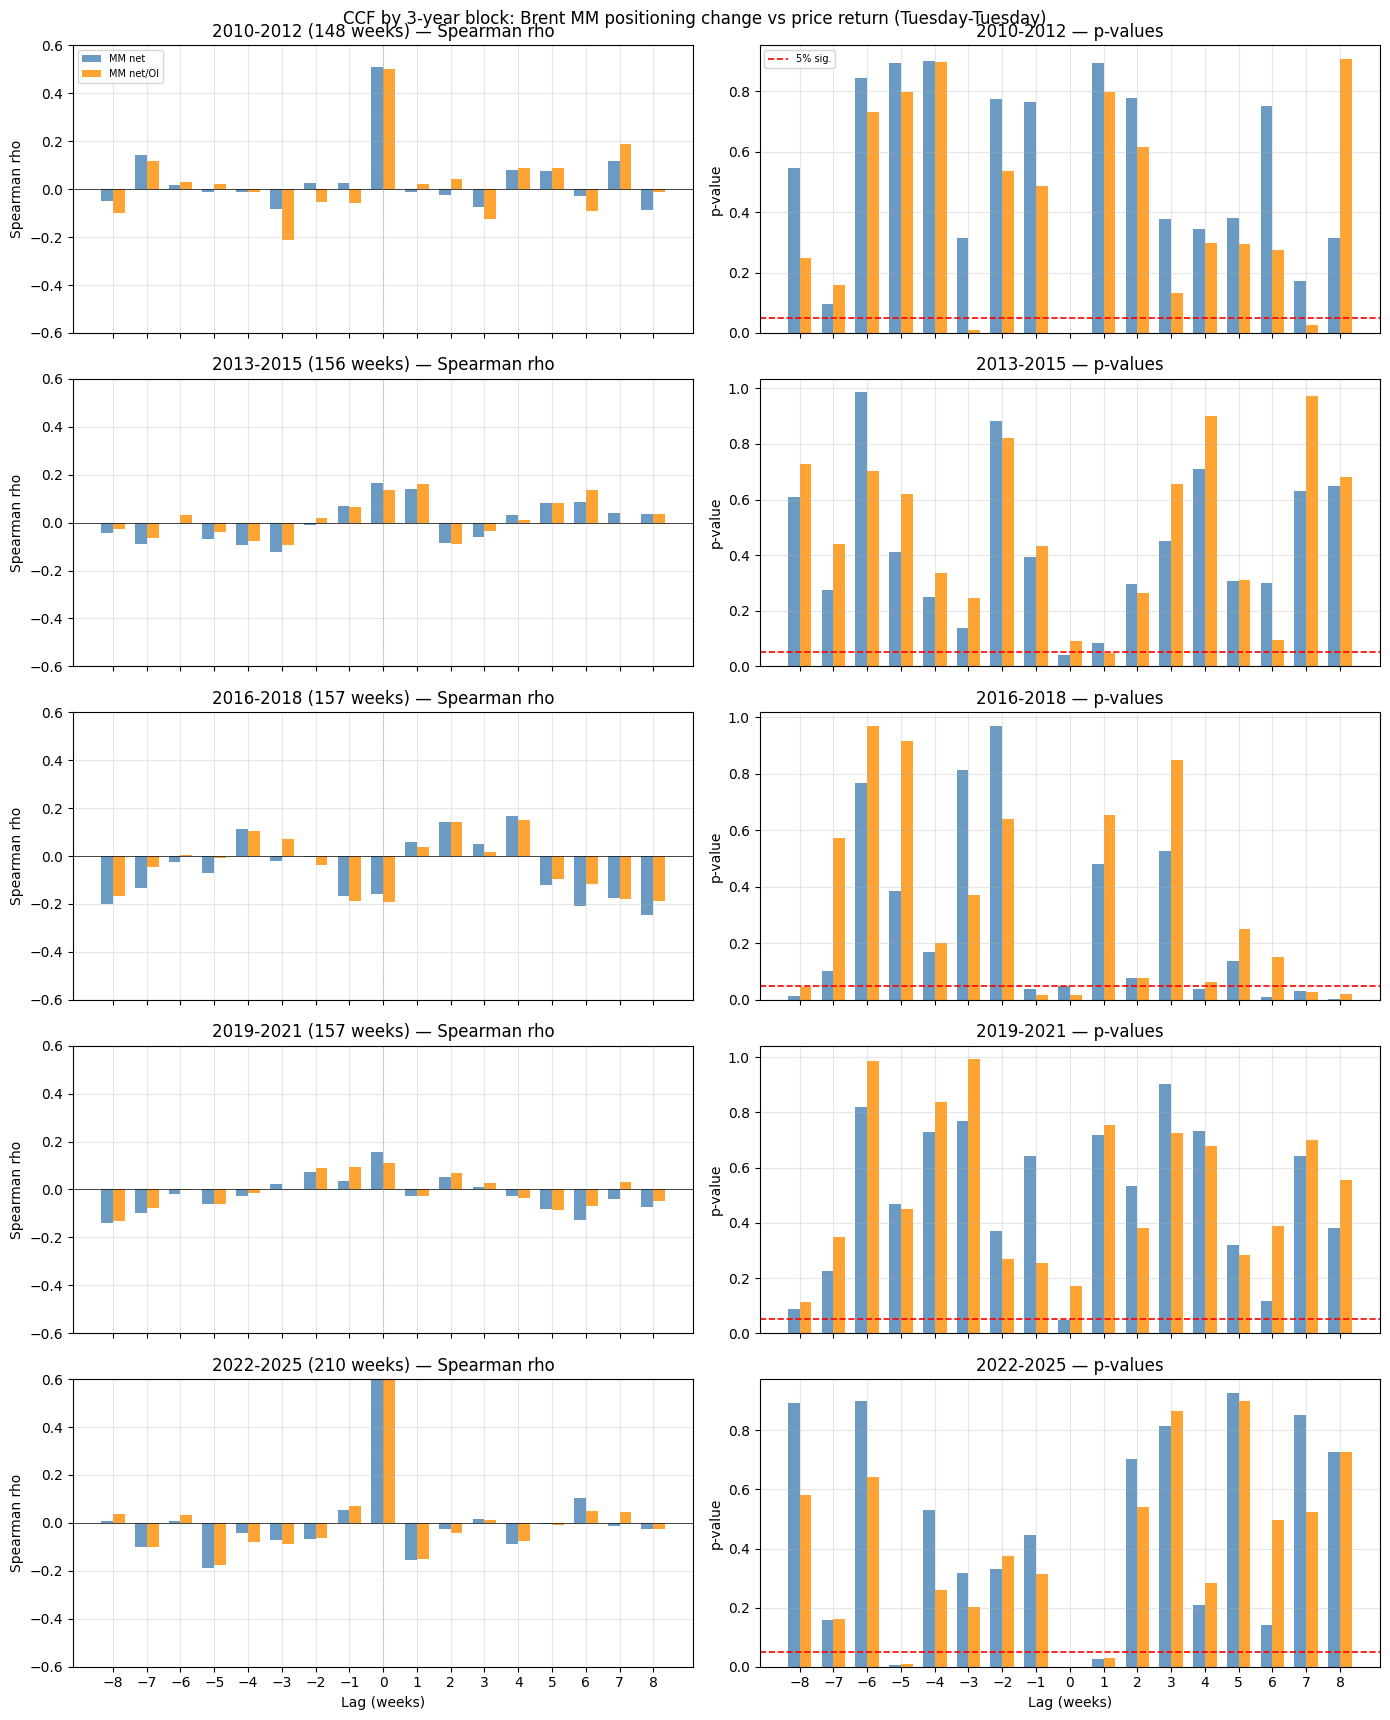

In [12]:
blocks_3y = [
    ('2010-2012', (2010, 2012)),
    ('2013-2015', (2013, 2015)),
    ('2016-2018', (2016, 2018)),
    ('2019-2021', (2019, 2021)),
    ('2022-2025', (2022, 2025)),
]

fig, axes = plt.subplots(len(blocks_3y), 2, figsize=(14, 3.5 * len(blocks_3y)),
                         sharex=True)
bar_width = 0.35

for row, (label, (y_start, y_end)) in enumerate(blocks_3y):
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    mm_oi_b = sub['mm_net_oi_chg'].values
    pr_b = sub['price_ret'].values

    lags_b, rhos_raw_b, pvals_raw_b = compute_ccf(mm_b, pr_b, MAX_LAG)
    _, rhos_oi_b, pvals_oi_b = compute_ccf(mm_oi_b, pr_b, MAX_LAG)
    x_pos = np.array(lags_b)

    ax = axes[row, 0]
    ax.bar(x_pos - bar_width/2, rhos_raw_b, bar_width,
           color='steelblue', alpha=0.8, label='MM net')
    ax.bar(x_pos + bar_width/2, rhos_oi_b, bar_width,
           color='darkorange', alpha=0.8, label='MM net/OI')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5, linestyle=':')
    ax.set_ylabel('Spearman rho')
    ax.set_title(f'{label} ({len(sub)} weeks) — Spearman rho')
    ax.set_ylim(-0.6, 0.6)
    if row == 0:
        ax.legend(fontsize=7, loc='upper left')

    ax = axes[row, 1]
    ax.bar(x_pos - bar_width/2, pvals_raw_b, bar_width,
           color='steelblue', alpha=0.8)
    ax.bar(x_pos + bar_width/2, pvals_oi_b, bar_width,
           color='darkorange', alpha=0.8)
    ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% sig.')
    ax.set_ylabel('p-value')
    ax.set_title(f'{label} — p-values')
    ax.set_xticks(lags_b)
    if row == 0:
        ax.legend(fontsize=7)

axes[-1, 0].set_xlabel('Lag (weeks)')
axes[-1, 1].set_xlabel('Lag (weeks)')
plt.suptitle('CCF by 3-year block: Brent MM positioning change vs price return (Tuesday-Tuesday)',
             fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY:
    print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))

for label, (y_start, y_end) in blocks_3y + [('Full sample', (2010, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    pr_b = sub['price_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                pr_b[k:] if k > 0 else pr_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], pr_b[:len(pr_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()

       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2012   148  +0.024  +0.025  +0.509  -0.011  -0.024
   2013-2015   156  -0.012  +0.069  +0.163  +0.140  -0.084
   2016-2018   157  -0.003  -0.167  -0.157  +0.057  +0.142
   2019-2021   157  +0.072  +0.037  +0.157  -0.029  +0.051
   2022-2025   210  -0.068  +0.053  +0.660  -0.154  -0.027
 Full sample   828  +0.006  -0.018  +0.215  -0.011  +0.016


## 6. Rolling stability of key lags

Are the lead/lag relationships stable over time? Compute the
lag -1, 0, +1 correlations on a rolling 104-week (2-year) window.

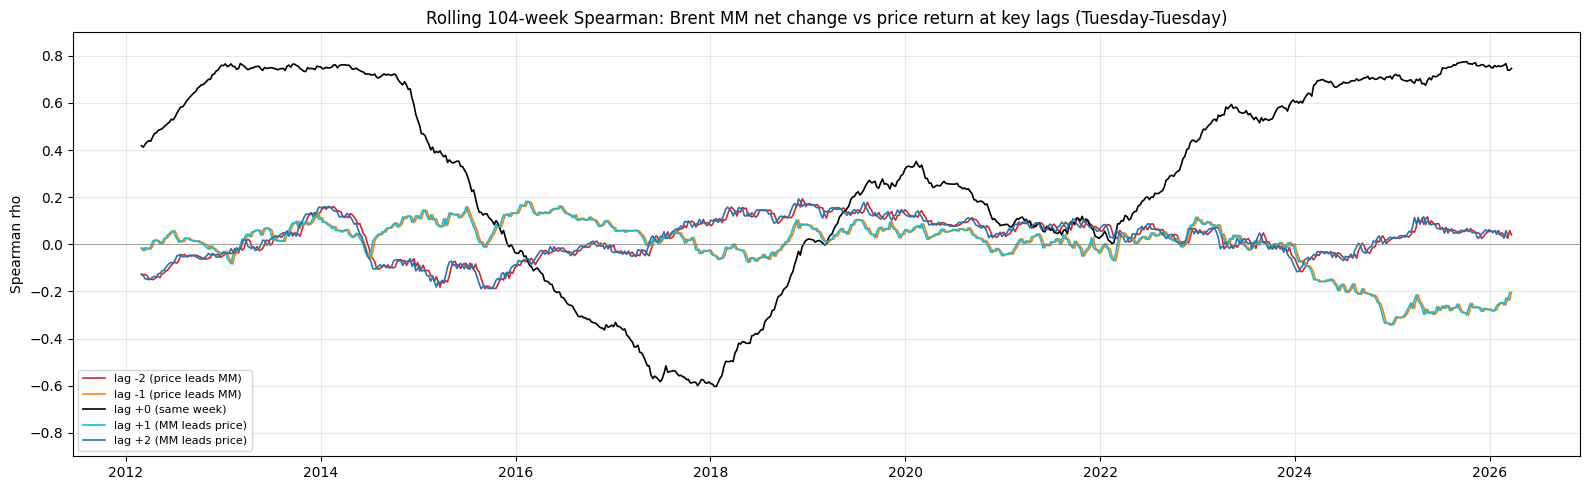

In [14]:
WINDOW = 104  # 2 years
KEY_LAGS = [-2, -1, 0, 1, 2]

mm_vals = df['mm_net_chg'].values
price_vals = df['price_ret'].values

rolling_results = {}
for k in KEY_LAGS:
    mm_s = pd.Series(mm_vals)
    pr_s = pd.Series(price_vals)
    if k >= 0:
        aligned_mm = mm_s.iloc[:len(mm_s)-k] if k > 0 else mm_s
        aligned_pr = pr_s.shift(-k).iloc[:len(pr_s)-k] if k > 0 else pr_s
    else:
        aligned_mm = mm_s.shift(-k)
        aligned_pr = pr_s

    rhos = []
    for i in range(len(aligned_mm)):
        if i < WINDOW:
            rhos.append(np.nan)
            continue
        m_win = aligned_mm.iloc[i-WINDOW:i].values
        p_win = aligned_pr.iloc[i-WINDOW:i].values
        mask = ~(np.isnan(m_win) | np.isnan(p_win))
        if mask.sum() < 20:
            rhos.append(np.nan)
        else:
            rhos.append(sp_stats.spearmanr(m_win[mask], p_win[mask]).statistic)
    rolling_results[k] = rhos[:len(df)]

fig, ax = plt.subplots(figsize=(16, 5))
lag_colors = {-2: 'tab:red', -1: 'tab:orange', 0: 'black', 1: 'tab:cyan', 2: 'tab:blue'}
for k in KEY_LAGS:
    label = f'lag {k:+d}' + (' (price leads MM)' if k < 0 else ' (MM leads price)' if k > 0 else ' (same week)')
    vals = rolling_results[k]
    ax.plot(df['as_of_date'].iloc[:len(vals)], vals,
            label=label, color=lag_colors[k], lw=1.2)

ax.axhline(0, color='grey', lw=0.5)
ax.set_title(f'Rolling {WINDOW}-week Spearman: Brent MM net change vs price return at key lags (Tuesday-Tuesday)')
ax.set_ylabel('Spearman rho')
ax.set_ylim(-0.9, 0.9)
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

## 7. Cumulative P&L

In [15]:
df['price_chg'] = df['F1_RolledPrice'].diff()
df['pnl'] = df['mm_net'].shift(1) * df['price_chg']
pnl = df.dropna(subset=['pnl']).copy()
pnl['cum_pnl'] = pnl['pnl'].cumsum()

ann = np.sqrt(52)
sr = pnl['pnl'].mean() / pnl['pnl'].std() * ann
total = pnl['pnl'].sum()
print(f'Brent MM Net Position P&L (raw contracts):')
print(f'  Cumulative P&L: ${total:>14,.0f}')
print(f'  Sharpe Ratio:   {sr:+.2f}')
print(f'  Weeks:          {len(pnl)}')


Brent MM Net Position P&L (raw contracts):
  Cumulative P&L: $    23,211,167
  Sharpe Ratio:   +0.26
  Weeks:          839


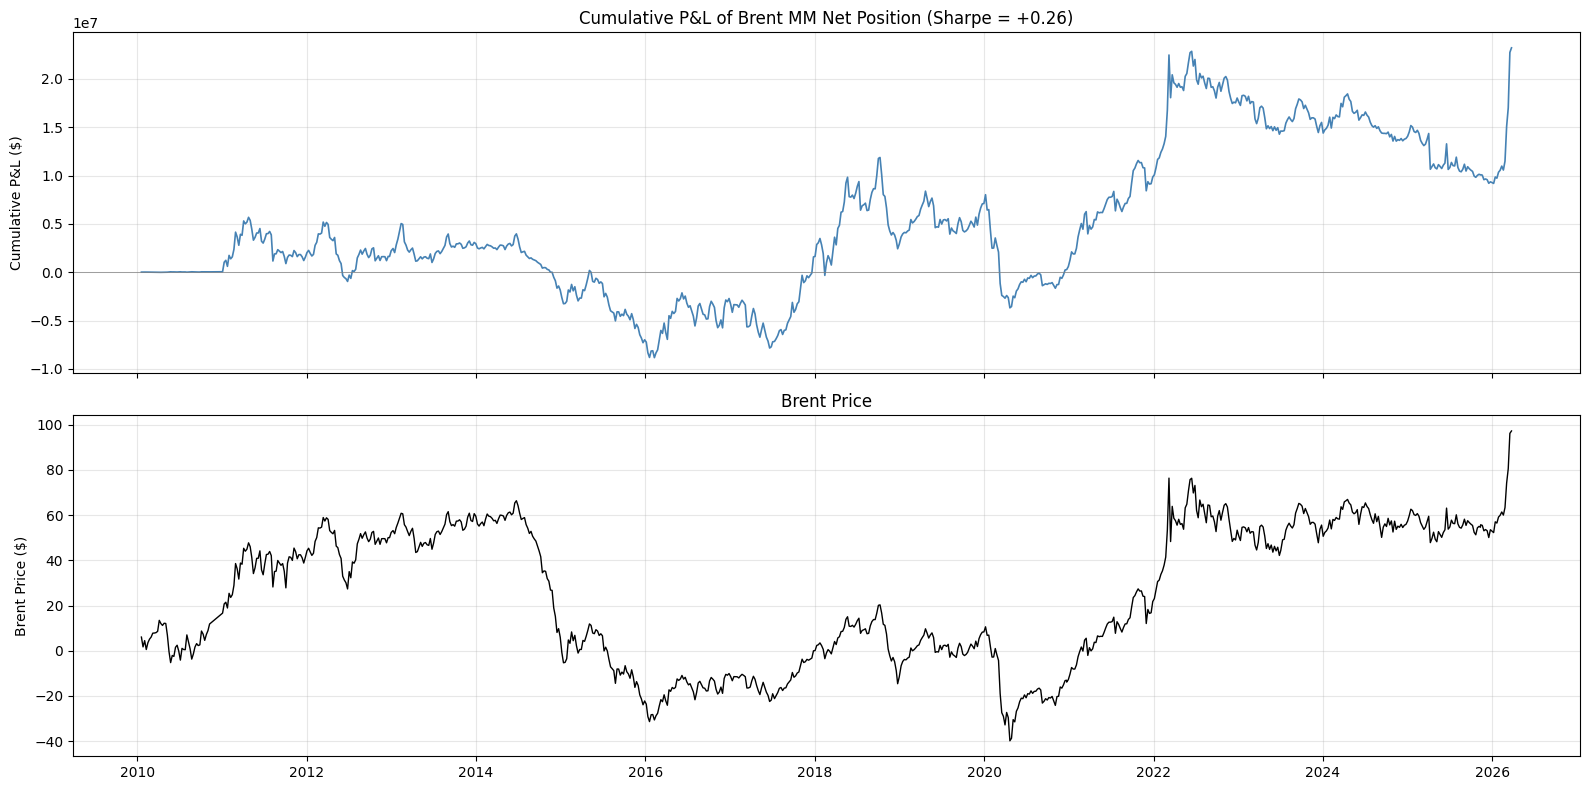

In [16]:
dt_pnl = pd.to_datetime(pnl['as_of_date'])
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
ax = axes[0]
ax.plot(dt_pnl, pnl['cum_pnl'], color='steelblue', lw=1.2)
ax.axhline(0, color='grey', lw=0.5)
ax.set_ylabel('Cumulative P&L ($)')
ax.set_title(f'Cumulative P&L of Brent MM Net Position (Sharpe = {sr:+.2f})')
ax = axes[1]
ax.plot(dt_pnl, pnl['F1_RolledPrice'], color='black', lw=1)
ax.set_ylabel('Brent Price ($)')
ax.set_title('Brent Price')
plt.tight_layout()
plt.show()


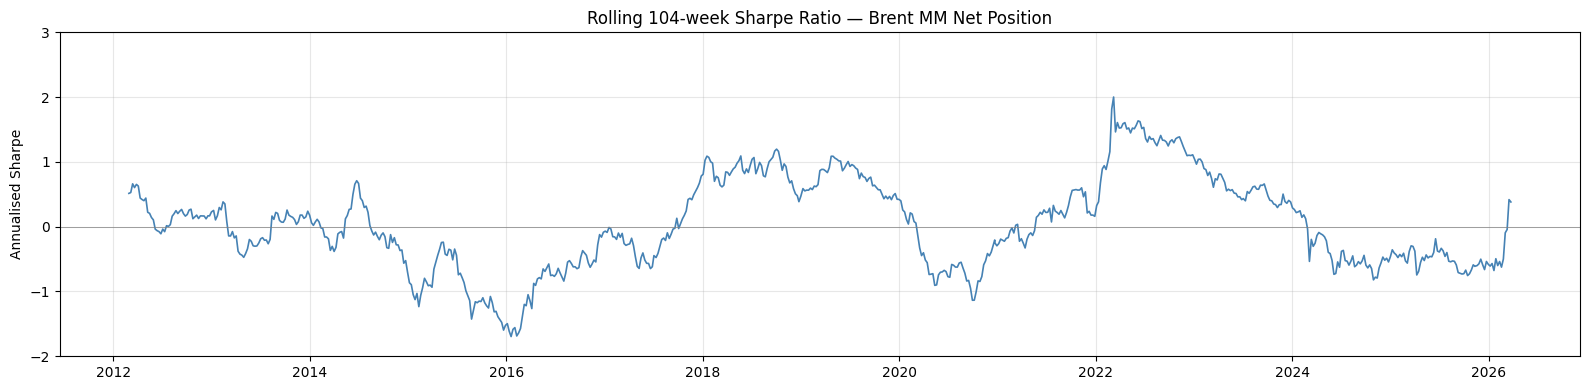

In [17]:
# Rolling 2-year Sharpe
ROLL_W = 104
ann = np.sqrt(52)
roll_sr = pnl['pnl'].rolling(ROLL_W).mean() / pnl['pnl'].rolling(ROLL_W).std() * ann

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(dt_pnl, roll_sr, color='steelblue', lw=1.2)
ax.axhline(0, color='grey', lw=0.5)
ax.set_ylabel('Annualised Sharpe')
ax.set_title(f'Rolling {ROLL_W}-week Sharpe Ratio — Brent MM Net Position')
ax.set_ylim(-2, 3)
plt.tight_layout()
plt.show()